# Train N2V with the Simulated galaxy

Note that here we have the choice of constrained N2V and standard N2V.

In [1]:
from tqdm import tqdm
import numpy as np
import pandas as pd
from pathlib import Path
from matplotlib import pyplot as plt

In [2]:
path = '../data saved/'

stamps_ori = np.load(path + 'stampcor.npy')
stamps_cle = np.load(path + 'stampcle.npy')

In [3]:
train_part = stamps_ori[:2000].copy()  # First 2000 samples
val_part = stamps_ori[2000:].copy()  # Remaining 1000 samples

In [4]:
import os
os.chdir('../pn2v/src/pn2v')
#os.chdir('../pn2v_ELU/src/pn2v')

from unet import UNet
from core import utils
from core import training
from core import prediction


In [5]:
device=utils.getDevice()
net = UNet(800, depth=3)
os.chdir('../../..')
path = './model saved'

trainHist, valHist = training.trainNetwork(net=net, trainData=train_part, valData=val_part,
                                           postfix='name_the_model', directory=path, noiseModel=None,
                                           device=device, numOfEpochs= 200, stepsPerEpoch=10, 
                                           virtualBatchSize=20, batchSize=20, learningRate=6e-4,patchSize=32)#7e-4#7e-5

CUDA available? True


/data/aai/scratch/jchan/denoise/PAUS/DenoisingPAUS/pn2v/src/pn2v/unet/model.py:215: FutureWarning: `nn.init.xavier_normal` is now deprecated in favor of `nn.init.xavier_normal_`.
  init.xavier_normal(m.weight)
/data/aai/scratch/jchan/denoise/PAUS/DenoisingPAUS/pn2v/src/pn2v/unet/model.py:216: FutureWarning: `nn.init.constant` is now deprecated in favor of `nn.init.constant_`.
  init.constant(m.bias, 0)
/data/aai/scratch/jchan/miniconda3/envs/denoise/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 0 finished      
avg. loss: 1.0063067704439164+-(2SEM)0.009401619170210592      
Epoch 1 finished      
avg. loss: 0.9824624866247177+-(2SEM)0.007322364369686227      
Epoch 2 finished      
avg. loss: 0.9859624624252319+-(2SEM)0.008489019375864718      
Epoch 3 finished      
avg. loss: 0.9869414657354355+-(2SEM)0.007439761698404155      
Epoch 4 finished      
avg. loss: 0.9877185553312302+-(2SEM)0.008510000967491575      
Epoch 5 finished      
avg. loss: 0.9854046404361725+-(2SEM)0.007334919799826436      
Epoch 6 finished      
avg. loss: 0.9837005853652954+-(2SEM)0.00917454786908213      
Epoch 7 finished      
avg. loss: 0.9882947623729705+-(2SEM)0.009239024004682066      
Epoch 8 finished      
avg. loss: 0.9809125810861588+-(2SEM)0.008905183336176369      
Epoch 9 finished      
avg. loss: 0.9831409603357315+-(2SEM)0.010182645142902243      
Epoch 10 finished      
avg. loss: 0.9772104799747467+-(2SEM)0.007463119788798388      
Epoch 11 finished      
avg. loss: 0.982021

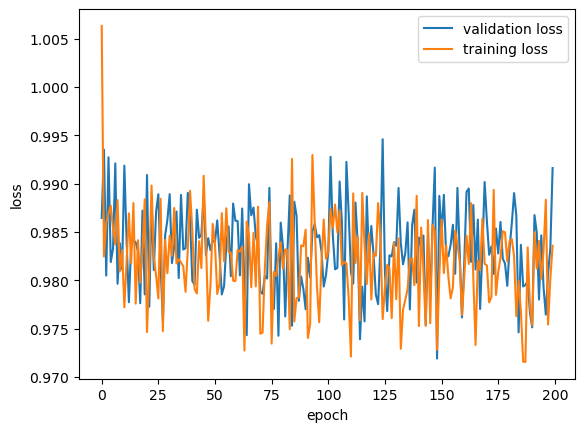

In [6]:
# Let's look at the training and validation loss
plt.xlabel('epoch')
plt.ylabel('loss')
plt.plot(valHist, label='validation loss')
plt.plot(trainHist, label='training loss')
plt.legend()
plt.show()

(-0.5, 95.5, 95.5, -0.5)

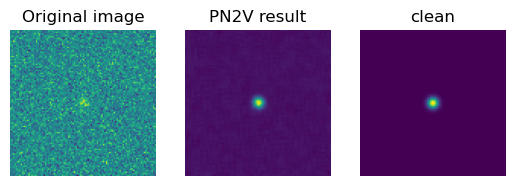

In [7]:
num = 68
n2vResult = prediction.tiledPredict(val_part[num], net ,ps=96, overlap=48,
                                            device=device, noiseModel=None)

fig, axes = plt.subplots(ncols=3)

im1 = axes[0].imshow(val_part[num])
axes[0].set_title('Original image')
axes[0].axis('off')

im2 = axes[1].imshow(n2vResult)
axes[1].set_title('PN2V result')
axes[1].axis('off')

im3 = axes[2].imshow(stamps_cle[2000+num])
axes[2].set_title('clean')
axes[2].axis('off')